In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report,ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [2]:
os.listdir()

['.DS_Store', '.ipynb_checkpoints', 'churn_analysis.ipynb']

In [3]:
os.getcwd()

'/Users/chiedu/Documents/april_data_science/customer_churn_analysis/notebooks'

In [4]:
parent_dir = os.path.abspath("..")
parent_dir

'/Users/chiedu/Documents/april_data_science/customer_churn_analysis'

In [5]:
file = os.path.join(parent_dir + "/data/telco_customer.csv")
file

'/Users/chiedu/Documents/april_data_science/customer_churn_analysis/data/telco_customer.csv'

In [6]:
df = pd.read_csv(file)

### Get the first 5 elements of the dataframe

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Check for duplicates

In [10]:
df.duplicated().any()

False

In [11]:
df.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

### Churn

In [13]:
churn_count = df["Churn"].value_counts()
churn_count

Churn
No     5174
Yes    1869
Name: count, dtype: int64

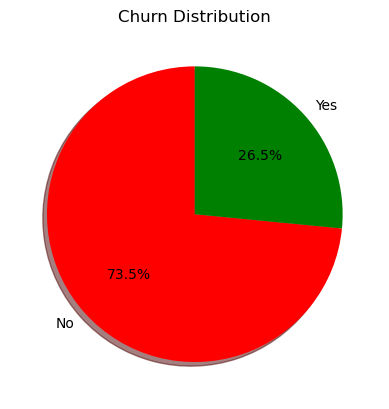

In [14]:
plt.pie(churn_count, labels=churn_count.index, autopct="%1.1f%%", startangle=90, colors=["red", "green"], shadow=True)
plt.title("Churn Distribution")
plt.savefig(f"{parent_dir}/images/churndistribution.png")

### Senior Citizens

In [15]:
senior_citizen_count = df["SeniorCitizen"].value_counts()
senior_citizen_count

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [16]:
senior_percentage = df.groupby("SeniorCitizen").size().reset_index(name="count")
senior_percentage

,SeniorCitizen,count
0,0,5901
1,1,1142


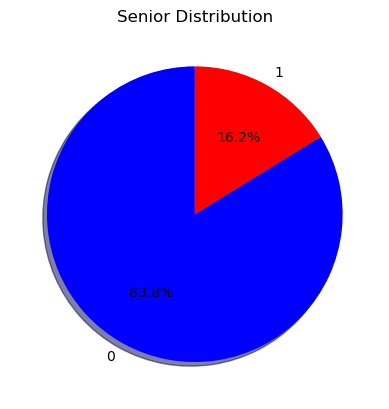

In [17]:
plt.pie(senior_citizen_count, labels=senior_citizen_count.index, autopct="%1.1f%%", startangle=90, colors=["blue", "red"], shadow=True)
plt.title("Senior Distribution")
plt.savefig(f"{parent_dir}/images/seniordistribution.png")

#### There are more non-senior citizens than senior citizens

In [18]:
senior_citizens = np.where(df["SeniorCitizen"] == 1)
df_senior_citizens = df.iloc[senior_citizens]

In [19]:
df_senior_citizens

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
34,3413-BMNZE,Male,1,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),45.25,45.25,No
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.10,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes


In [20]:
len(df_senior_citizens)

1142

### Non Senior Citizens

In [21]:
df_non_senior_citizens = df[df["SeniorCitizen"] == 0]
df_non_senior_citizens

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


In [22]:
len(df_non_senior_citizens)

5901

### Senior Citizens With Partners

In [23]:
df["Partner"].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [24]:
senior_citizens_with_partners = lambda x: (x["SeniorCitizen"] == 1) & (x["Partner"] == "Yes")
df_senior_citizens_with_partners = df[df.apply(senior_citizens_with_partners, axis=1)]

In [25]:
df_senior_citizens_with_partners

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
52,6575-SUVOI,Female,1,Yes,No,25,Yes,Yes,DSL,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),69.50,1752.65,No
53,7495-OOKFY,Female,1,Yes,No,8,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),80.65,633.30,Yes
54,4667-QONEA,Female,1,Yes,Yes,60,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),74.85,4456.35,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7010,0723-DRCLG,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,74.45,Yes
7015,0666-UXTJO,Male,1,Yes,No,34,Yes,No,Fiber optic,No,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),85.20,2874.45,No
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.10,No


In [26]:
len(df_senior_citizens_with_partners)

573

### Senior Citizens Without Partners

In [27]:
print(len(df_senior_citizens) - len(df_senior_citizens_with_partners))

569


### Non Senior Citizens With Partners

In [28]:
df_non_senior_citizens_with_partners = df.query("SeniorCitizen == 0 and Partner == 'Yes'")

In [29]:
df_non_senior_citizens_with_partners

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
10,9763-GRSKD,Male,0,Yes,Yes,13,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.10,No
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7024,7398-LXGYX,Male,0,Yes,No,44,Yes,Yes,Fiber optic,Yes,...,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),84.80,3626.35,No
7028,9281-CEDRU,Female,0,Yes,No,68,Yes,No,DSL,No,...,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),64.10,4326.25,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No


In [30]:
len(df_non_senior_citizens_with_partners)

2829

### Non Senior Citizens Without Partners

In [31]:
print(len(df_non_senior_citizens) - len(df_non_senior_citizens_with_partners))

3072


### Senior Partners Gender

In [32]:
df["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [33]:
df_senior_citizens_male = df.query("SeniorCitizen == 1 and gender == 'Male'")
df_senior_citizens_male

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
34,3413-BMNZE,Male,1,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),45.25,45.25,No
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7007,2274-XUATA,Male,1,Yes,No,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),63.10,4685.55,No
7015,0666-UXTJO,Male,1,Yes,No,34,Yes,No,Fiber optic,No,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),85.20,2874.45,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.10,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes


In [34]:
df_senior_citizens_female = df.query("SeniorCitizen == 1 and gender == 'Female'")
df_senior_citizens_female

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No
52,6575-SUVOI,Female,1,Yes,No,25,Yes,Yes,DSL,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),69.50,1752.65,No
53,7495-OOKFY,Female,1,Yes,No,8,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),80.65,633.30,Yes
54,4667-QONEA,Female,1,Yes,Yes,60,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),74.85,4456.35,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6993,6583-QGCSI,Female,1,Yes,No,50,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,88.05,4367.35,Yes
7008,1980-KXVPM,Female,1,No,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.05,256.25,Yes
7010,0723-DRCLG,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,74.45,Yes
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No


### Non Senior Partners Gender

In [35]:
non_senior_citizens_male = np.where((df["SeniorCitizen"] == 0) & (df["gender"] == "Male"))
df_non_senior_citizens_male = df.iloc[non_senior_citizens_male]
df_non_senior_citizens_male

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0550-DCXLH,Male,0,No,No,13,Yes,No,DSL,No,...,No,Yes,Yes,Yes,Month-to-month,No,Mailed check,73.35,931.55,No
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No


In [36]:
df_non_senior_citizens_female = df[(df["SeniorCitizen"] == 0) & (df["gender"] == "Female")]
df_non_senior_citizens_female

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No


### Dependents

In [37]:
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

### Senior Citizens With Dependents

In [38]:
senior_citizens_with_dependents = lambda x: (x["SeniorCitizen"] == 1) & (x["Dependents"] == "Yes")
df_senior_citizens_with_dependents = df[df.apply(senior_citizens_with_dependents, axis=1)]
df_senior_citizens_with_dependents

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
54,4667-QONEA,Female,1,Yes,Yes,60,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),74.85,4456.35,No
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
72,1891-QRQSA,Male,1,Yes,Yes,64,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),111.60,7099.00,No
140,3146-MSEGF,Female,1,Yes,Yes,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),88.05,6425.65,No
308,3167-SNQPL,Male,1,Yes,Yes,38,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,101.15,3741.85,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6235,5180-UCIIQ,Male,1,Yes,Yes,22,No,No phone service,DSL,Yes,...,No,No,No,Yes,Month-to-month,No,Mailed check,40.05,880.20,Yes
6346,9661-MHUMO,Male,1,Yes,Yes,1,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),49.25,49.25,Yes
6446,2205-LPVGL,Male,1,Yes,Yes,58,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,One year,Yes,Bank transfer (automatic),89.85,5125.75,No
6451,4868-AADLV,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,116.25,7862.25,No


### Senior Citizens Without Dependents

In [39]:
senior_citizens_without_dependents = lambda x: (x["SeniorCitizen"] == 1) & (x["Dependents"] == "No")
df_senior_citizens_without_dependents = df[df.apply(senior_citizens_without_dependents, axis=1)]
df_senior_citizens_without_dependents

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
34,3413-BMNZE,Male,1,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),45.25,45.25,No
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.10,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes


### Non Senior Citizens With Dependents

In [40]:
non_senior_citizens_with_dependents = lambda x: (x["SeniorCitizen"] == 0) & (x["Dependents"] == "Yes")
df_non_senior_citizens_with_dependents = df[df.apply(non_senior_citizens_with_dependents, axis=1)]
df_non_senior_citizens_with_dependents

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No
10,9763-GRSKD,Male,0,Yes,Yes,13,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No
17,9959-WOFKT,Male,0,No,Yes,71,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),106.70,7382.25,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7018,1122-JWTJW,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.65,70.65,Yes
7020,9837-FWLCH,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.20,239.00,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No


### Non Senior Citizens Without Dependents

In [41]:
non_senior_citizens_without_dependents = lambda x: (x["SeniorCitizen"] == 0) & (x["Dependents"] == "No")
df_non_senior_citizens_without_dependents = df[df.apply(non_senior_citizens_without_dependents, axis=1)]
df_non_senior_citizens_without_dependents

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No


### Senior Citizens Who Have Partners and Dependents

In [42]:
conditions = [df["SeniorCitizen"] == 1,
              df["Partner"] == "Yes",
              df["Dependents"] == "Yes"
             ]


df_senior_citizens_with_dependents_and_partners = df[np.logical_and.reduce(conditions)]
df_senior_citizens_with_dependents_and_partners

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
54,4667-QONEA,Female,1,Yes,Yes,60,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),74.85,4456.35,No
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
72,1891-QRQSA,Male,1,Yes,Yes,64,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),111.60,7099.00,No
140,3146-MSEGF,Female,1,Yes,Yes,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),88.05,6425.65,No
308,3167-SNQPL,Male,1,Yes,Yes,38,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,101.15,3741.85,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6235,5180-UCIIQ,Male,1,Yes,Yes,22,No,No phone service,DSL,Yes,...,No,No,No,Yes,Month-to-month,No,Mailed check,40.05,880.20,Yes
6346,9661-MHUMO,Male,1,Yes,Yes,1,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),49.25,49.25,Yes
6446,2205-LPVGL,Male,1,Yes,Yes,58,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,One year,Yes,Bank transfer (automatic),89.85,5125.75,No
6451,4868-AADLV,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,116.25,7862.25,No


### Senior Citizens Who Have Dependents and No Partners

In [43]:
print(len(df_senior_citizens_with_dependents) - len(df_senior_citizens_with_dependents_and_partners))

8


### Non Senior Citizens Who Have Dependents and Partners

In [44]:
conditions = [df["SeniorCitizen"] == 0,
              df["Partner"] == "Yes",
              df["Dependents"] == "Yes"
             ]


df_non_senior_citizens_with_dependents_and_partners = df[np.logical_and.reduce(conditions)]
df_non_senior_citizens_with_dependents_and_partners

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
10,9763-GRSKD,Male,0,Yes,Yes,13,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No
18,4190-MFLUW,Female,0,Yes,Yes,10,Yes,No,DSL,No,...,Yes,Yes,No,No,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes
24,6322-HRPFA,Male,0,Yes,Yes,49,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.60,2970.30,No
26,6467-CHFZW,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7018,1122-JWTJW,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.65,70.65,Yes
7020,9837-FWLCH,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.20,239.00,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No


### Non Senior Citizens Who Have Dependents and No Partners

In [45]:
print(len(df_non_senior_citizens_with_dependents) - len(df_non_senior_citizens_with_dependents_and_partners))

353


### Tenure

In [46]:
df["tenure"].value_counts()

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

In [47]:
### Highest Tenure
df["tenure"].max()

72

In [48]:
### Shortest Tenure
df["tenure"].min()

0

In [49]:
### Average Tenure
df["tenure"].mean()

32.37114865824223

### Citizens With Zero Tenure

In [50]:
df_citizens_with_zero_tenure = df[df["tenure"]== 0]
df_citizens_with_zero_tenure

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [51]:
df_citizens_with_zero_tenure["SeniorCitizen"].value_counts()

SeniorCitizen
0    11
Name: count, dtype: int64

#### All citizens with zero tenure are non senior citizens and they all have dependents. 

### Phone Service

In [52]:
df["PhoneService"].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

#### Most Citizens use the Phone Service

In [53]:
df_citizens_without_phone_service= df[df["PhoneService"]== "No"]
df_citizens_without_phone_service

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
27,8665-UTDHZ,Male,0,Yes,Yes,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,30.20,30.20,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003,4501-VCPFK,Male,0,No,No,26,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,No,Electronic check,35.75,1022.50,No
7007,2274-XUATA,Male,1,Yes,No,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),63.10,4685.55,No
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,No


### Citizens Without a Phone Service

In [54]:
df_citizens_without_phone_service["SeniorCitizen"].value_counts()


SeniorCitizen
0    578
1    104
Name: count, dtype: int64

### Senior Citizens Without a Phone Service

In [55]:
print(len(df_senior_citizens) - df_citizens_without_phone_service["SeniorCitizen"].value_counts()[1])

1038


### Non Senior Citizens Without a Phone Service

In [56]:
print(len(df_non_senior_citizens) - df_citizens_without_phone_service["SeniorCitizen"].value_counts()[0])

5323


### Multiple Lines

In [57]:
df["MultipleLines"].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

### Senior Citizens With Multiple Lines

In [58]:
senior_citizens_with_multipleLines = np.where((df["MultipleLines"] == "Yes")
                                              & (df["SeniorCitizen"] == 1))
df_senior_citizens_with_multipleLines = df.iloc[senior_citizens_with_multipleLines]
df_senior_citizens_with_multipleLines

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No
52,6575-SUVOI,Female,1,Yes,No,25,Yes,Yes,DSL,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),69.50,1752.65,No
53,7495-OOKFY,Female,1,Yes,No,8,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),80.65,633.30,Yes
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7010,0723-DRCLG,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,74.45,Yes
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.10,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes


### Senior Citizens Without Multiple Lines

In [59]:
senior_citizens_without_multipleLines = np.where((df["MultipleLines"] == "No")
                                              & (df["SeniorCitizen"] == 1))
df_senior_citizens_without_multipleLines = df.iloc[senior_citizens_without_multipleLines]
df_senior_citizens_without_multipleLines

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
34,3413-BMNZE,Male,1,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),45.25,45.25,No
54,4667-QONEA,Female,1,Yes,Yes,60,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),74.85,4456.35,No
78,0191-ZHSKZ,Male,1,No,No,30,Yes,No,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,74.75,2111.30,No
91,2424-WVHPL,Male,1,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,74.70,74.70,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6900,7921-LMDFQ,Male,1,No,No,51,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),94.00,4905.75,No
6942,3454-JFUBC,Male,1,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.00,1396.00,No
6962,0886-QGENL,Female,1,Yes,No,27,Yes,No,Fiber optic,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.25,2754.45,Yes
6973,9972-VAFJJ,Female,1,Yes,No,53,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,No,One year,Yes,Electronic check,94.00,4871.45,No


### Senior Citizens With Multiple Lines Who Have Dependents

In [60]:
df_senior_citizens_with_multipleLines["Dependents"].value_counts()

Dependents
No     609
Yes     56
Name: count, dtype: int64

#### Most senior citizens who have multiple lines have no dependents

In [61]:
df_senior_citizens_with_multipleLines["Partner"].value_counts()

Partner
Yes    369
No     296
Name: count, dtype: int64

### Senior Citizens With Multiple Lines Who Have No Dependents

In [62]:
df_senior_citizens_with_multipleLines_and_no_dependents = df_senior_citizens_with_multipleLines[df_senior_citizens_with_multipleLines["Dependents"] == "No"]
df_senior_citizens_with_multipleLines_and_no_dependents

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No
52,6575-SUVOI,Female,1,Yes,No,25,Yes,Yes,DSL,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),69.50,1752.65,No
53,7495-OOKFY,Female,1,Yes,No,8,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),80.65,633.30,Yes
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7010,0723-DRCLG,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,74.45,Yes
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.10,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes


In [63]:
df_senior_citizens_with_multipleLines_and_no_dependents["Partner"].value_counts()

Partner
Yes    316
No     293
Name: count, dtype: int64

### InternetService

In [64]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [65]:
df.pivot_table(index="gender", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
gender,,,
Female,1188,1553,747
Male,1233,1543,779


In [66]:
df.pivot_table(index="gender", aggfunc="sum",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
gender,,,
Female,123,424,21
Male,136,407,31


In [67]:
grouped_internetservice = df.groupby(["InternetService", "Churn"]).size().reset_index(name="count")
grouped_internetservice

,InternetService,Churn,count
0,DSL,No,1962
1,DSL,Yes,459
2,Fiber optic,No,1799
3,Fiber optic,Yes,1297
4,No,No,1413
5,No,Yes,113


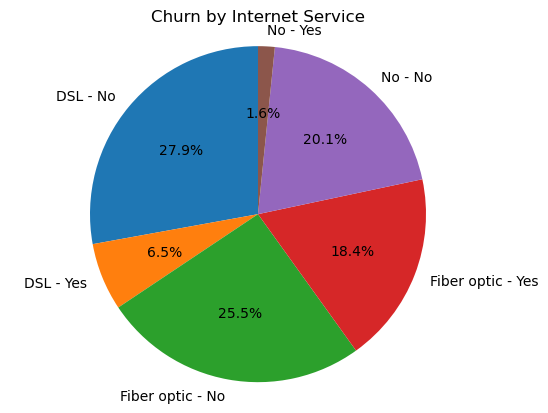

In [68]:
plt.figure()
plt.pie(
    grouped_internetservice["count"],
    labels=grouped_internetservice["InternetService"].astype(str) + " - " + grouped_internetservice["Churn"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Churn by Internet Service")
plt.axis("equal")
plt.savefig(f"{parent_dir}/images/churninternet_servicecount.png")
plt.show()

### Online Security

In [69]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [70]:
df.pivot_table(index="OnlineSecurity", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
OnlineSecurity,,,
No,1241.0,2257.0,NaN
No internet service,NaN,NaN,1526.0
Yes,1180.0,839.0,NaN


In [71]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### OnlineBackup

In [72]:
df["OnlineBackup"].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [73]:
df.pivot_table(index="OnlineBackup", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
OnlineBackup,,,
No,1335.0,1753.0,NaN
No internet service,NaN,NaN,1526.0
Yes,1086.0,1343.0,NaN


### DeviceProtection

In [74]:
df["DeviceProtection"].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [75]:
df.pivot_table(index="DeviceProtection", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
DeviceProtection,,,
No,1356.0,1739.0,NaN
No internet service,NaN,NaN,1526.0
Yes,1065.0,1357.0,NaN


### TechSupport

In [76]:
df["TechSupport"].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [77]:
df.pivot_table(index="TechSupport", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
TechSupport,,,
No,1243.0,2230.0,NaN
No internet service,NaN,NaN,1526.0
Yes,1178.0,866.0,NaN


### StreamingTV

In [78]:
df["StreamingTV"].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [79]:
df.pivot_table(index="StreamingTV", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
StreamingTV,,,
No,1464.0,1346.0,NaN
No internet service,NaN,NaN,1526.0
Yes,957.0,1750.0,NaN


### StreamingMovies

In [80]:
df["StreamingMovies"].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [81]:
df.pivot_table(index="StreamingMovies", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
StreamingMovies,,,
No,1440.0,1345.0,NaN
No internet service,NaN,NaN,1526.0
Yes,981.0,1751.0,NaN


### Contract

In [82]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [83]:
df.pivot_table(index="Contract", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,1223,2128,524
One year,570,539,364
Two year,628,429,638


In [84]:
df.pivot_table(index="Contract", aggfunc="sum",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,159,636,12
One year,50,124,16
Two year,50,71,24


### PaperlessBilling

In [85]:
df["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [86]:
df.pivot_table(index="PaperlessBilling", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
PaperlessBilling,,,
No,1091,701,1080
Yes,1330,2395,446


### PaymentMethod

In [87]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [88]:
df.pivot_table(index="PaymentMethod", aggfunc="count",  columns="InternetService", values="SeniorCitizen")

InternetService,DSL,Fiber optic,No
PaymentMethod,,,
Bank transfer (automatic),566,646,332
Credit card (automatic),594,597,331
Electronic check,648,1595,122
Mailed check,613,258,741


### MonthlyCharges

In [89]:
df["MonthlyCharges"].value_counts()

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
23.65      1
114.70     1
43.65      1
87.80      1
78.70      1
Name: count, Length: 1585, dtype: int64

In [90]:
df["MonthlyCharges"].max()

118.75

In [91]:
df["MonthlyCharges"].min()

18.25

### TotalCharges

In [92]:
df["TotalCharges"].value_counts()

TotalCharges
20.20      11
19.75       9
20.05       8
19.90       8
19.65       8
           ..
6849.40     1
692.35      1
130.15      1
3211.90     1
6844.50     1
Name: count, Length: 6530, dtype: int64

In [93]:
df["TotalCharges"].max()

8684.8

In [94]:
df["TotalCharges"].min()

18.8

### Churn

In [95]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [96]:
df_churn_yes = df[df["Churn"] == "Yes"]
df_churn_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7021,1699-HPSBG,Male,0,No,No,12,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Electronic check,59.80,727.80,Yes
7026,8775-CEBBJ,Female,0,No,No,9,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes


In [97]:
df_churn_yes["SeniorCitizen"].value_counts()

SeniorCitizen
0    1393
1     476
Name: count, dtype: int64

In [98]:
df_churn_yes["gender"].value_counts()

gender
Female    939
Male      930
Name: count, dtype: int64

## PLOTTING

<Axes: xlabel='SeniorCitizen', ylabel='gender'>

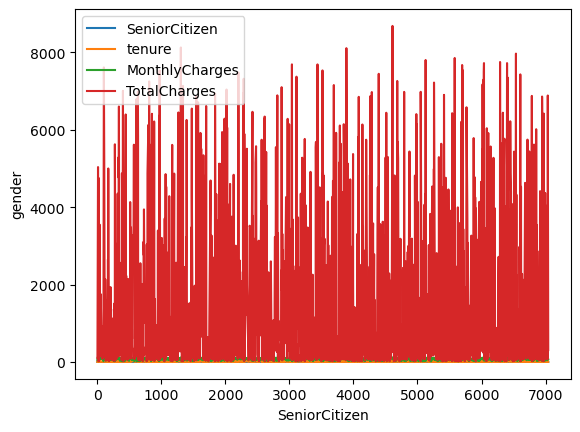

In [99]:
df_churn_yes.plot(kind="line", xlabel="SeniorCitizen", ylabel="gender")

In [100]:
df_churn_yes.reset_index(inplace=True, drop=True)

In [101]:
df_churn_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
3,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,Male,0,No,No,12,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Electronic check,59.80,727.80,Yes
1865,8775-CEBBJ,Female,0,No,No,9,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes
1866,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes
1867,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes


<Axes: xlabel='SeniorCitizen', ylabel='gender'>

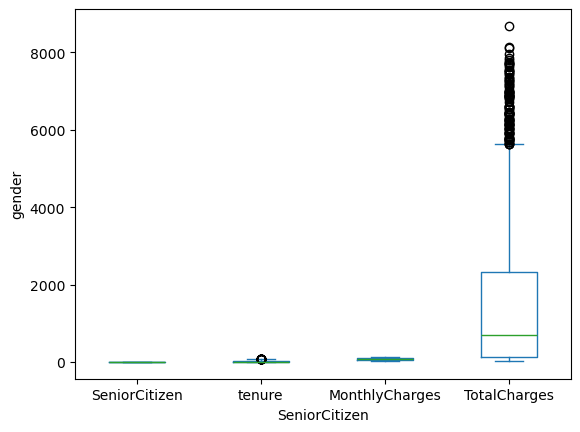

In [102]:
df_churn_yes.plot(kind="box", xlabel="SeniorCitizen", ylabel="gender")

Text(0.5, 1.0, 'Senior Citizen vs Churn')

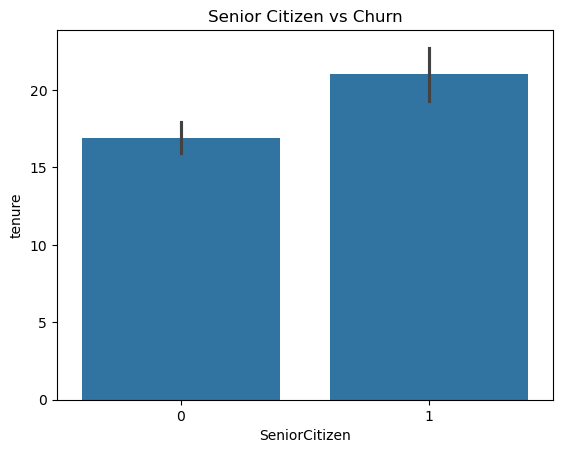

In [103]:
sns.barplot(df_churn_yes, x="SeniorCitizen", y="tenure")
plt.title("Senior Citizen vs Churn")

Text(0.5, 1.0, 'Senior Citizen vs Churn')

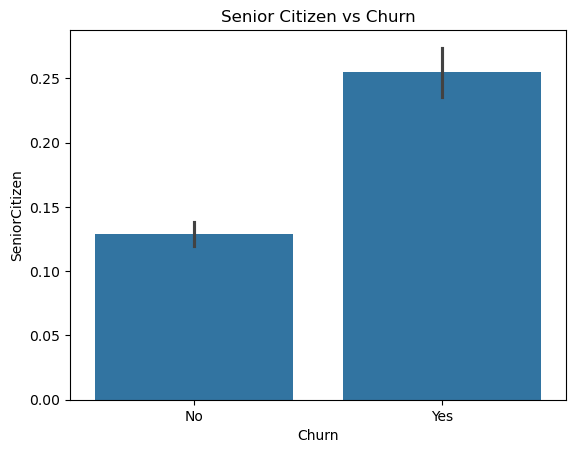

In [104]:
sns.barplot(df, x="Churn", y="SeniorCitizen")
plt.title("Senior Citizen vs Churn")

In [105]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

### Groupby

In [106]:
gender_group = df.groupby("gender")
gender_group

In [107]:
gender_group.groups

{'Female': [0, 4, 5, 7, 8, 15, 16, 18, 19, 23, 25, 29, 30, 32, 35, 37, 39, 41, 42, 43, 44, 45, 47, 49, 50, 51, 52, 53, 54, 56, 58, 59, 60, 63, 64, 65, 67, 68, 71, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 86, 87, 88, 93, 95, 99, 101, 103, 106, 107, 111, 112, 113, 114, 116, 117, 118, 120, 121, 123, 124, 126, 130, 131, 135, 136, 137, 139, 140, 141, 142, 145, 150, 152, 154, 155, 156, 160, 161, 162, 164, 166, 169, 171, 173, 174, 175, 176, 177, 178, 180, ...], 'Male': [1, 2, 3, 6, 9, 10, 11, 12, 13, 14, 17, 20, 21, 22, 24, 26, 27, 28, 31, 33, 34, 36, 38, 40, 46, 48, 55, 57, 61, 62, 66, 69, 70, 72, 73, 78, 85, 89, 90, 91, 92, 94, 96, 97, 98, 100, 102, 104, 105, 108, 109, 110, 115, 119, 122, 125, 127, 128, 129, 132, 133, 134, 138, 143, 144, 146, 147, 148, 149, 151, 153, 157, 158, 159, 163, 165, 167, 168, 170, 172, 179, 182, 183, 186, 187, 190, 191, 194, 196, 197, 198, 199, 202, 203, 204, 206, 207, 209, 210, 212, ...]}

In [108]:
gender_group.groups.keys()

dict_keys(['Female', 'Male'])

In [109]:
gender_group.get_group("Female")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No


In [110]:
 gender_group.get_group("Male")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [111]:
gender_n_seniorcitizen_group = df.groupby(by=["gender", "SeniorCitizen"])
gender_n_seniorcitizen_group

In [112]:
gender_n_seniorcitizen_group.groups.keys()

dict_keys([('Female', 0), ('Female', 1), ('Male', 0), ('Male', 1)])

In [113]:
non_female_citizens = gender_n_seniorcitizen_group.get_group(('Female', 0))
non_female_citizens

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No


<Axes: xlabel='tenure'>

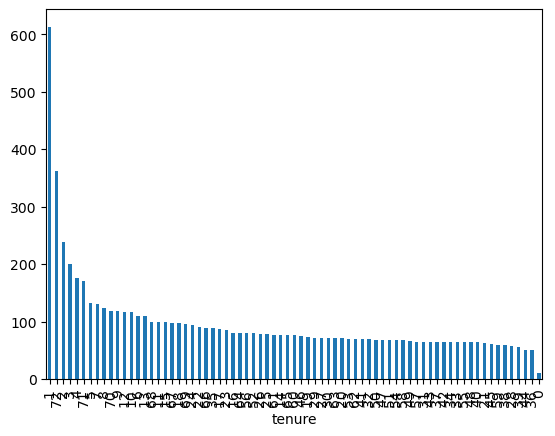

In [114]:
df["tenure"].value_counts().plot(kind="bar")

### PLOT

<Axes: xlabel='SeniorCitizen'>

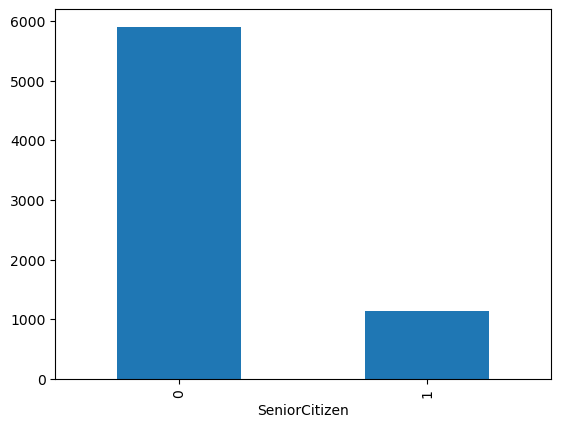

In [115]:
df["SeniorCitizen"].value_counts().plot(kind="bar")

<Axes: xlabel='Partner'>

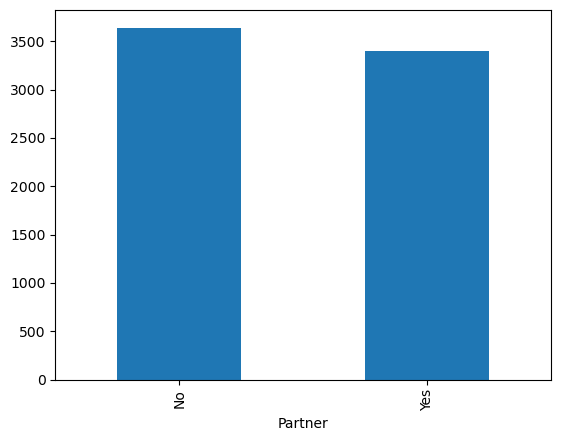

In [116]:
df["Partner"].value_counts().plot(kind="bar")

<Axes: xlabel='SeniorCitizen'>

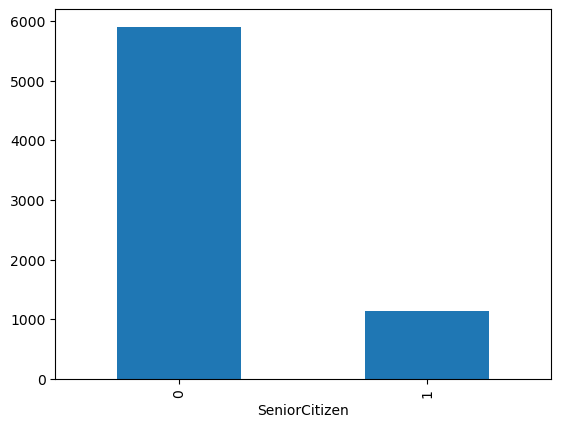

In [117]:
df["SeniorCitizen"].value_counts().plot(kind="bar")

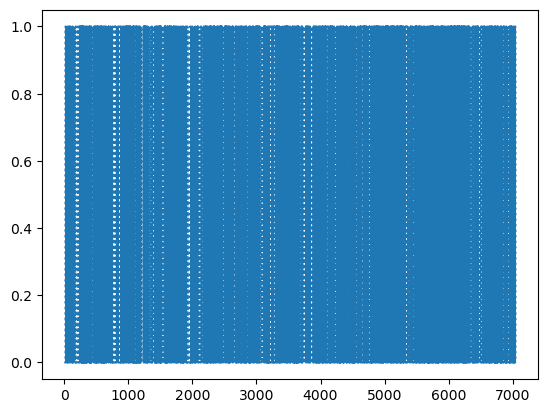

In [118]:
plt.plot(df["SeniorCitizen"], linestyle=":")

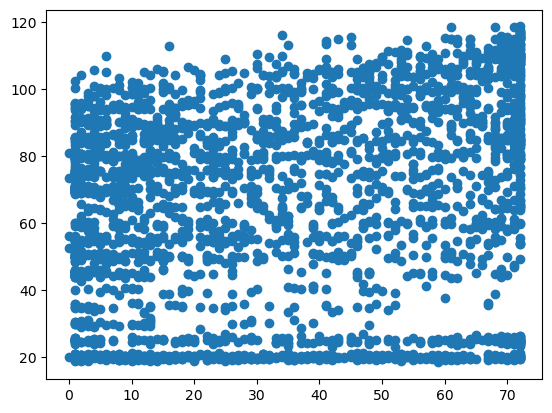

In [119]:
plt.scatter(non_female_citizens["tenure"], non_female_citizens["MonthlyCharges"])

In [120]:
female_citizens = gender_n_seniorcitizen_group.get_group(('Female', 1))
female_citizens

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No
52,6575-SUVOI,Female,1,Yes,No,25,Yes,Yes,DSL,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),69.50,1752.65,No
53,7495-OOKFY,Female,1,Yes,No,8,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),80.65,633.30,Yes
54,4667-QONEA,Female,1,Yes,Yes,60,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),74.85,4456.35,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6993,6583-QGCSI,Female,1,Yes,No,50,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,88.05,4367.35,Yes
7008,1980-KXVPM,Female,1,No,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.05,256.25,Yes
7010,0723-DRCLG,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,74.45,Yes
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No


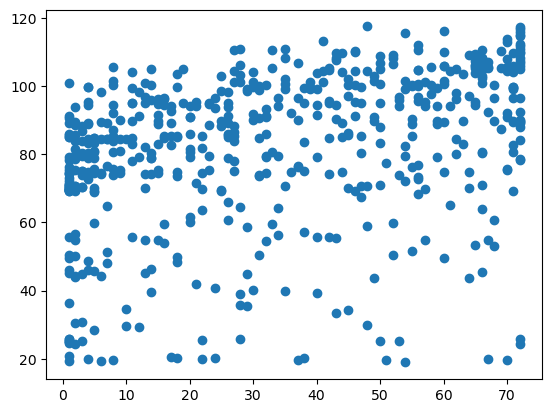

In [121]:
plt.scatter(female_citizens["tenure"], female_citizens["MonthlyCharges"])

In [122]:
seniorcitizen_group = df.groupby(["gender", "SeniorCitizen"]).size().reset_index(name="count")
print(seniorcitizen_group)

   gender  SeniorCitizen  count
0  Female              0   2920
1  Female              1    568
2    Male              0   2981
3    Male              1    574


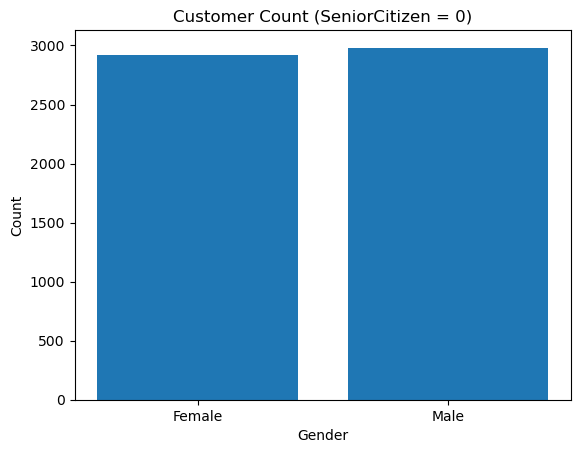

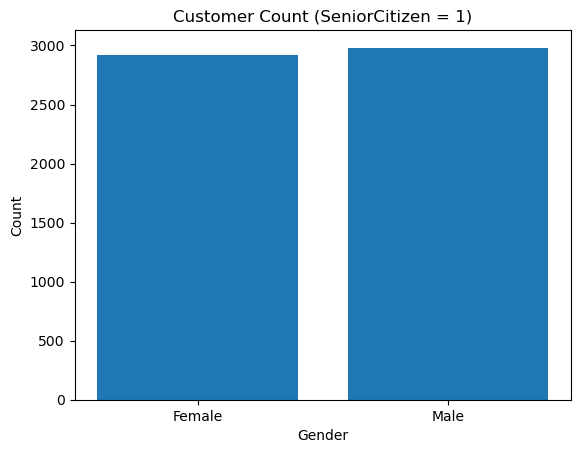

In [123]:
for senior_status in seniorcitizen_group["SeniorCitizen"].unique():
    subset = seniorcitizen_group[seniorcitizen_group["SeniorCitizen"] == 0]
    # print(subset)
    
    plt.figure()
    plt.bar(subset["gender"], subset["count"])
    plt.title(f"Customer Count (SeniorCitizen = {senior_status})")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.show()

In [124]:
gender_n_seniorcitizen_group

In [125]:
churn_grouped = df.groupby(["SeniorCitizen", "Contract", "Churn"]).size().reset_index(name="count")
churn_grouped

,SeniorCitizen,Contract,Churn,count
0,0,Month-to-month,No,1854
1,0,Month-to-month,Yes,1214
2,0,One year,No,1146
3,0,One year,Yes,137
4,0,Two year,No,1508
5,0,Two year,Yes,42
6,1,Month-to-month,No,366
7,1,Month-to-month,Yes,441
8,1,One year,No,161
9,1,One year,Yes,29


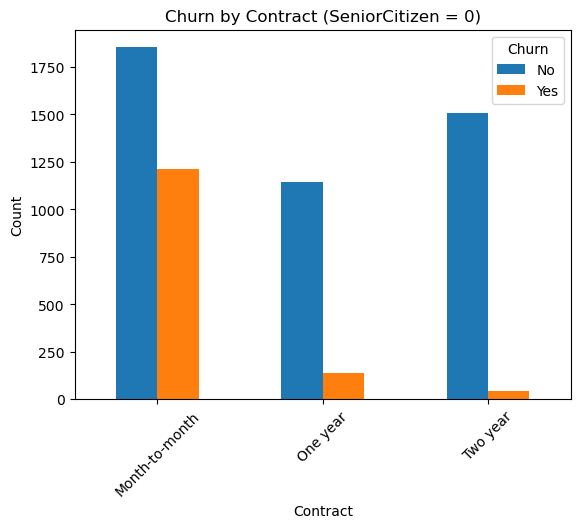

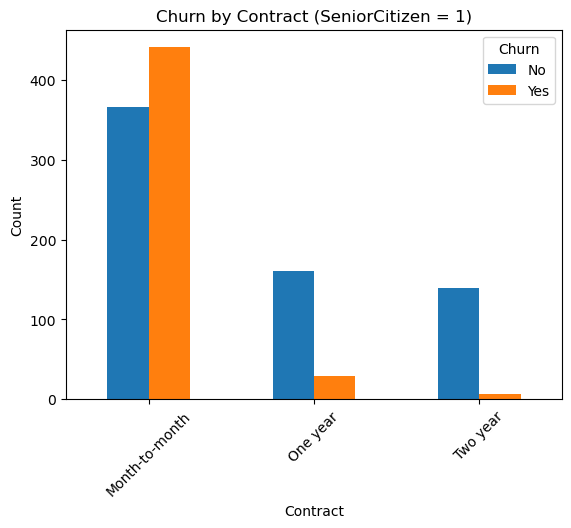

In [126]:
### CHURN YES REPRESENTS CITIZENS THAT LEFT THE TELCO 

for senior in churn_grouped["SeniorCitizen"].unique():
    subset = churn_grouped[churn_grouped["SeniorCitizen"] == senior]
    
    pivot = subset.pivot(index="Contract", columns="Churn", values="count")
    
    pivot.plot(kind="bar")
    plt.title(f"Churn by Contract (SeniorCitizen = {senior})")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

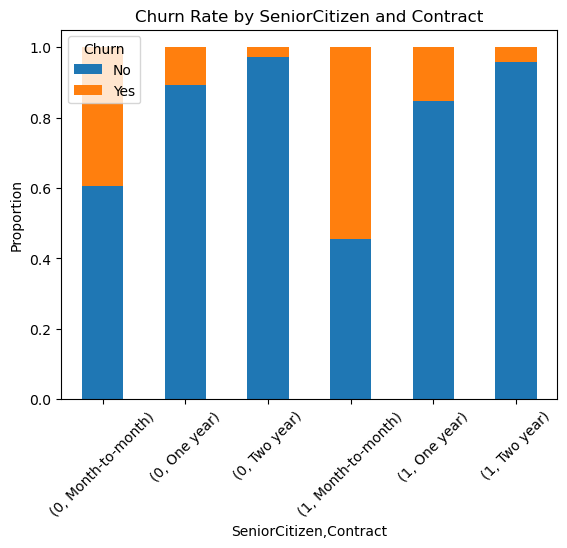

In [127]:
normalized = df.groupby(["SeniorCitizen", "Contract"])["Churn"].value_counts(normalize=True).unstack()

normalized.plot(kind="bar", stacked=True)
plt.title("Churn Rate by SeniorCitizen and Contract")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

In [128]:
churn_grouped_gender = df.groupby(
    ["SeniorCitizen", "gender", "Contract", "Churn"]
).size().reset_index(name="count")

churn_grouped_gender

,SeniorCitizen,gender,Contract,Churn,count
0,0,Female,Month-to-month,No,905
1,0,Female,Month-to-month,Yes,621
2,0,Female,One year,No,558
3,0,Female,One year,Yes,59
4,0,Female,Two year,No,758
5,0,Female,Two year,Yes,19
6,0,Male,Month-to-month,No,949
7,0,Male,Month-to-month,Yes,593
8,0,Male,One year,No,588
9,0,Male,One year,Yes,78


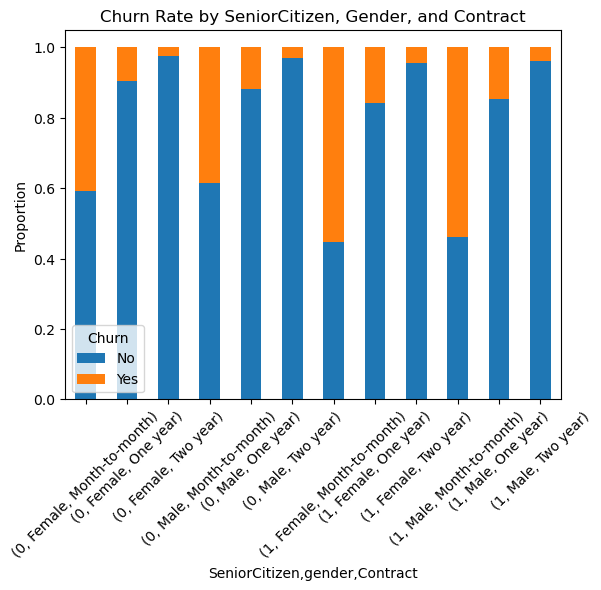

In [129]:
normalized = df.groupby(
    ["SeniorCitizen", "gender", "Contract"]
)["Churn"].value_counts(normalize=True).unstack()

normalized.plot(kind="bar", stacked=True)
plt.title("Churn Rate by SeniorCitizen, Gender, and Contract")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

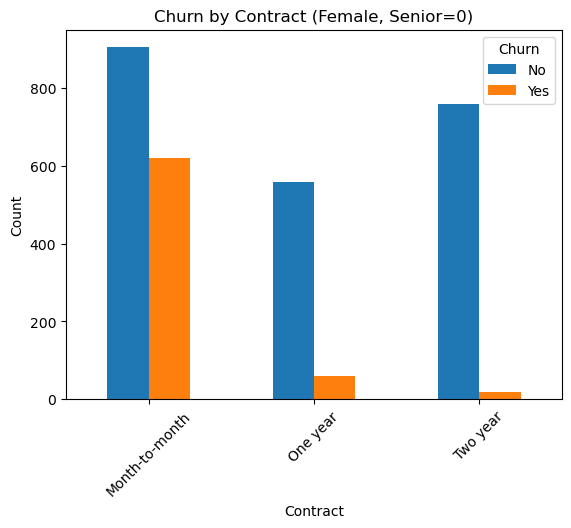

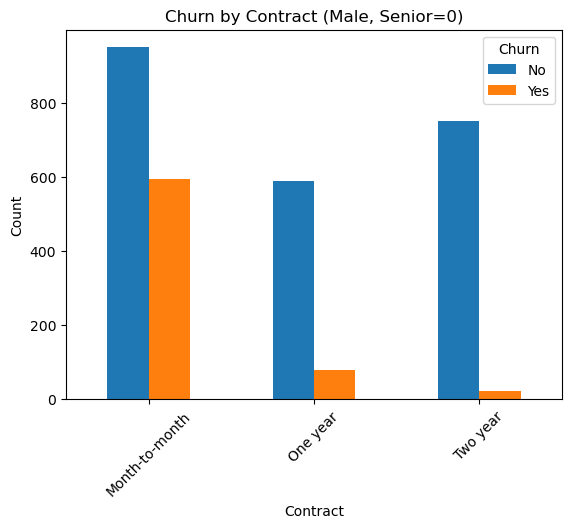

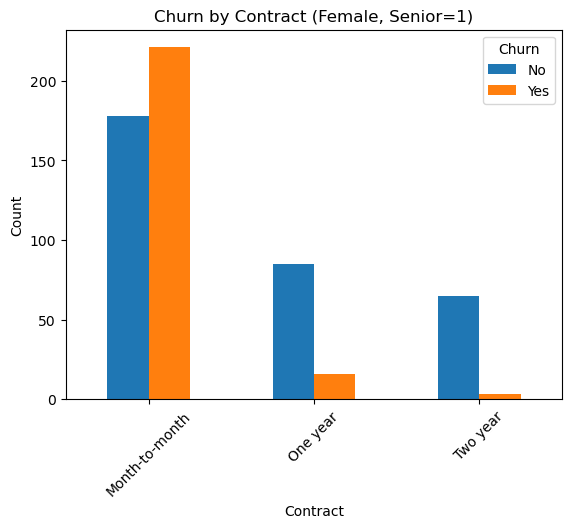

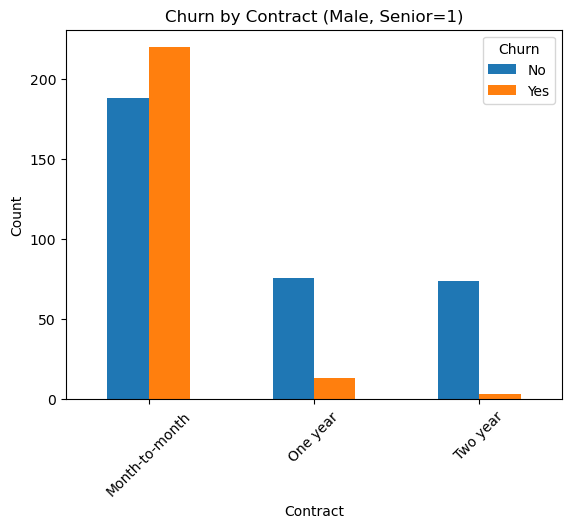

In [130]:
for senior in churn_grouped_gender["SeniorCitizen"].unique():
    for gender in churn_grouped_gender["gender"].unique():
        
        subset = churn_grouped_gender[
            (churn_grouped_gender["SeniorCitizen"] == senior) &
            (churn_grouped_gender["gender"] == gender)
        ]
        
        pivot = subset.pivot(index="Contract", columns="Churn", values="count")
        
        pivot.plot(kind="bar")
        plt.title(f"Churn by Contract ({gender}, Senior={senior})")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

In [131]:
churn_grouped_partner = df.groupby(
    ["SeniorCitizen", "Partner", "Contract", "Churn"]
).size().reset_index(name="count")

churn_grouped_partner

,SeniorCitizen,Partner,Contract,Churn,count
0,0,No,Month-to-month,No,1185
1,0,No,Month-to-month,Yes,849
2,0,No,One year,No,520
3,0,No,One year,Yes,57
4,0,No,Two year,No,445
5,0,No,Two year,Yes,16
6,0,Yes,Month-to-month,No,669
7,0,Yes,Month-to-month,Yes,365
8,0,Yes,One year,No,626
9,0,Yes,One year,Yes,80


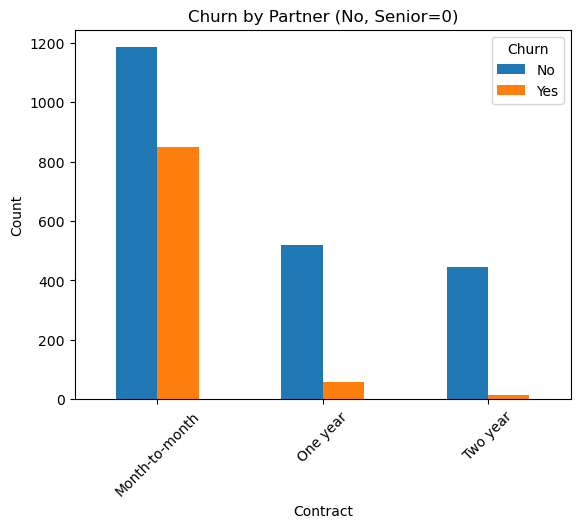

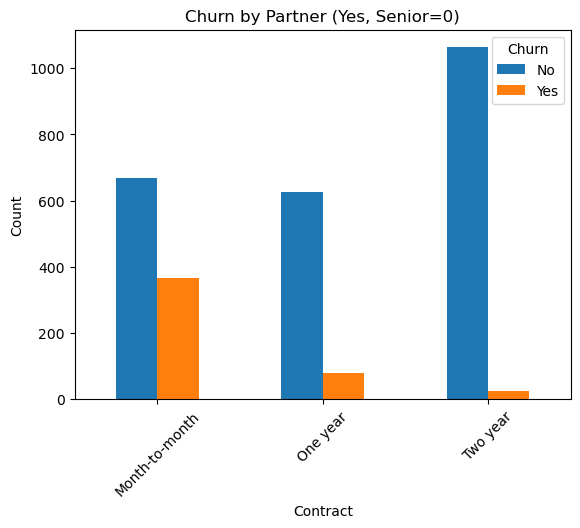

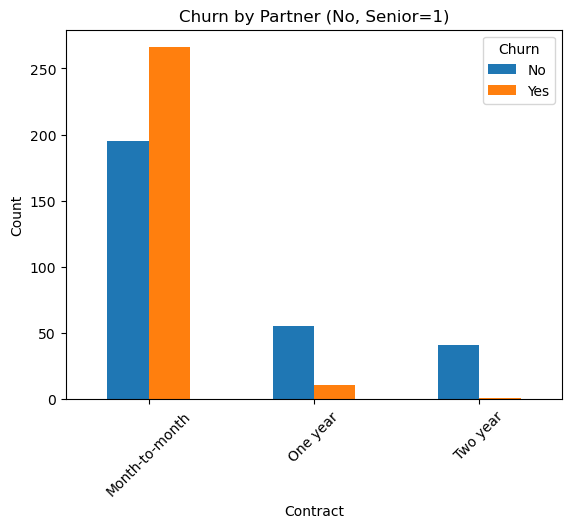

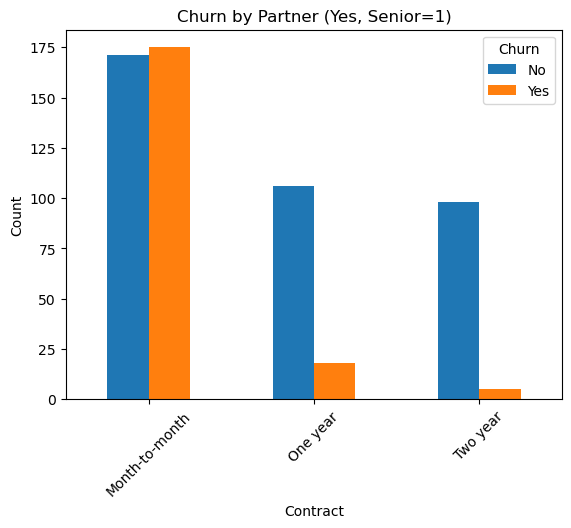

In [132]:
for senior in churn_grouped_partner["SeniorCitizen"].unique():
    for partner in churn_grouped_partner["Partner"].unique():
        
        subset = churn_grouped_partner[
            (churn_grouped_partner["SeniorCitizen"] == senior) &
            (churn_grouped_partner["Partner"] == partner)
        ]
        
        pivot = subset.pivot(index="Contract", columns="Churn", values="count")
        
        pivot.plot(kind="bar")
        plt.title(f"Churn by Partner ({partner}, Senior={senior})")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

In [133]:
# sns.barplot(df, x="Churn", y="SeniorCitizen")
# plt.title("Senior Citizen vs Churn")

churn_grouped_senior = df.groupby(
    ["SeniorCitizen", "Churn"]
).size().reset_index(name="count")

churn_grouped_senior

,SeniorCitizen,Churn,count
0,0,No,4508
1,0,Yes,1393
2,1,No,666
3,1,Yes,476


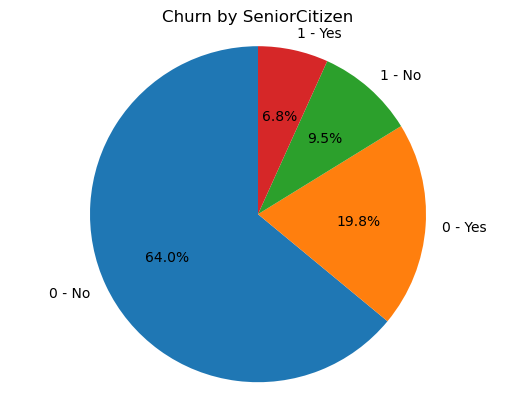

In [134]:
plt.figure()
plt.pie(
    churn_grouped_senior["count"],
    labels=churn_grouped_senior["SeniorCitizen"].astype(str) + " - " + churn_grouped_senior["Churn"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Churn by SeniorCitizen")
plt.axis("equal")
plt.show()


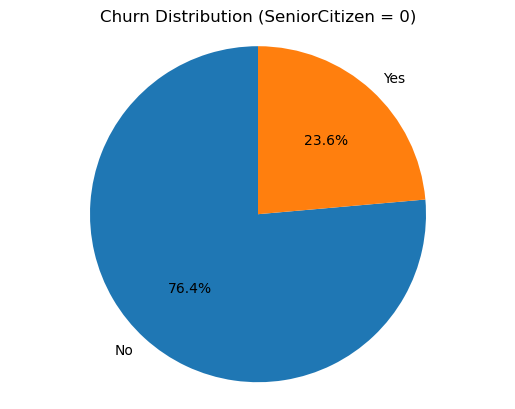

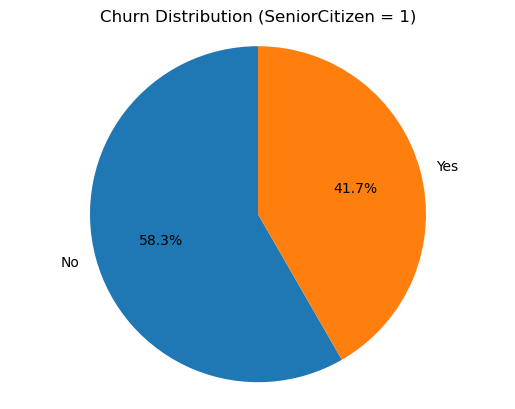

In [135]:
for senior in df["SeniorCitizen"].unique():
    subset = df[df["SeniorCitizen"] == senior]["Churn"].value_counts()
    
    plt.figure()
    plt.pie(
        subset,
        labels=subset.index,
        autopct="%1.1f%%",
        startangle=90
    )
    plt.title(f"Churn Distribution (SeniorCitizen = {senior})")
    plt.axis("equal")
    plt.show()

In [136]:
df_senior_citizens

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
34,3413-BMNZE,Male,1,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),45.25,45.25,No
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.10,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes


In [137]:
senior_deps_grouped = df_senior_citizens.groupby(["gender", "Partner", "Dependents"]).size().reset_index(name="count")
senior_deps_grouped

,gender,Partner,Dependents,count
0,Female,No,No,317
1,Female,No,Yes,3
2,Female,Yes,No,209
3,Female,Yes,Yes,39
4,Male,No,No,244
5,Male,No,Yes,5
6,Male,Yes,No,281
7,Male,Yes,Yes,44


In [138]:
pivot = senior_deps_grouped.pivot_table(
    index="gender",
    columns=["Partner", "Dependents"],
    values="count",
    fill_value=0
)

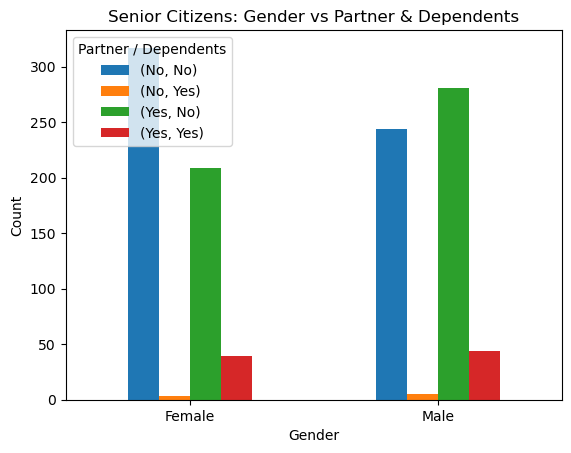

In [139]:
pivot.plot(kind="bar")

plt.title("Senior Citizens: Gender vs Partner & Dependents")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Partner / Dependents")
plt.savefig(f"{parent_dir}/images/seniorcitizenspartnersdeps.png")


In [140]:
grouped_churn_contract = df.groupby(["Contract", "Churn"]).size().reset_index(name="count")
grouped_churn_contract

,Contract,Churn,count
0,Month-to-month,No,2220
1,Month-to-month,Yes,1655
2,One year,No,1307
3,One year,Yes,166
4,Two year,No,1647
5,Two year,Yes,48


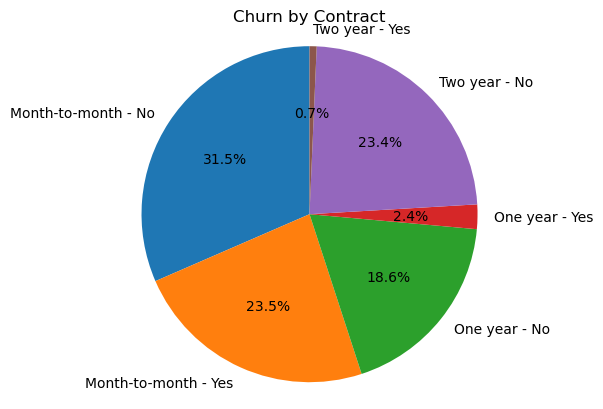

In [141]:
plt.figure()
plt.pie(
    grouped_churn_contract["count"],
    labels=grouped_churn_contract["Contract"].astype(str) + " - " + grouped_churn_contract["Churn"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Churn by Contract")
plt.axis("equal")
plt.savefig(f"{parent_dir}/images/churncontractcount.png")
plt.show()

# MACHINE LEARNING

In [142]:
df_corr = df.copy()
for c in df_corr.select_dtypes("object").columns:
    df_corr[c] = LabelEncoder().fit_transform(df_corr[c])
corr = df_corr.corr()

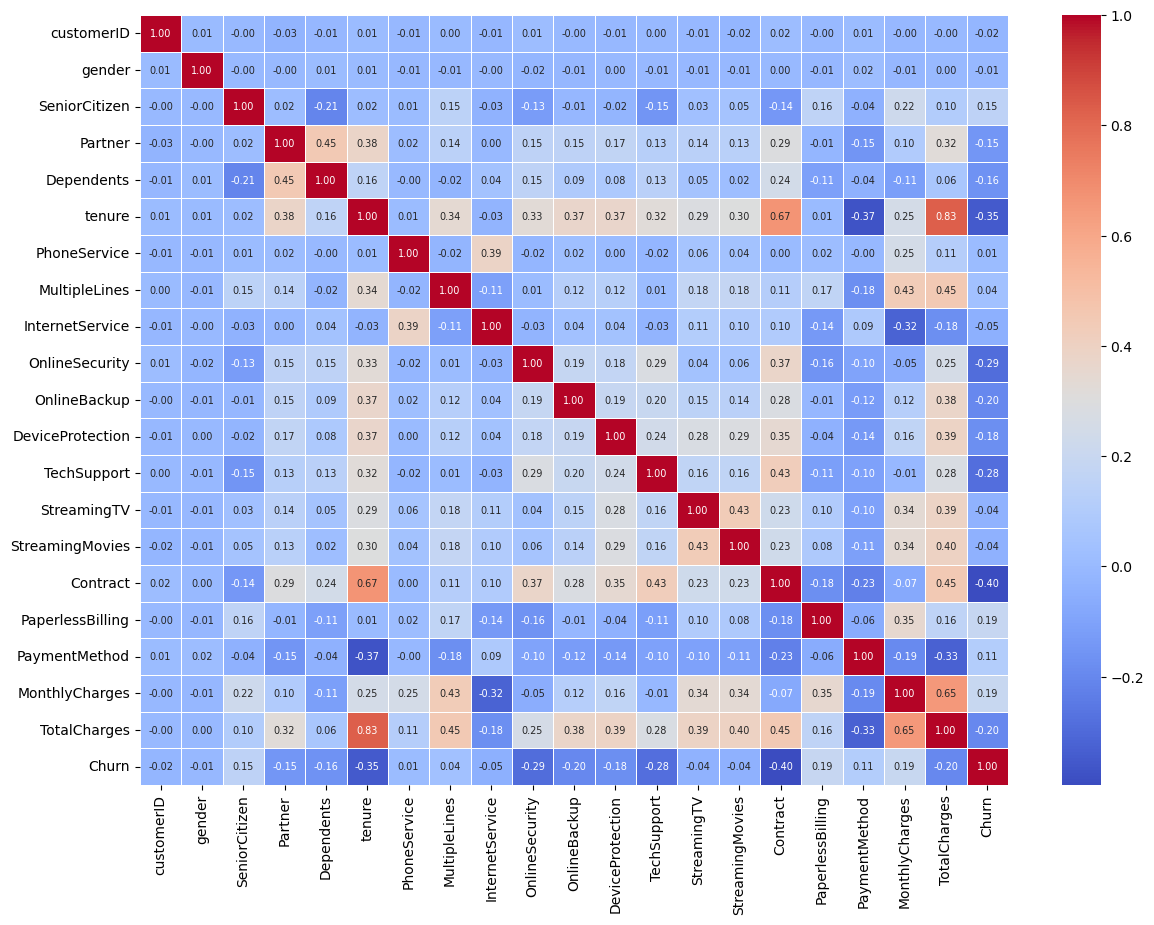

In [143]:
fig, ax = plt.subplots(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size":7})
plt.show()

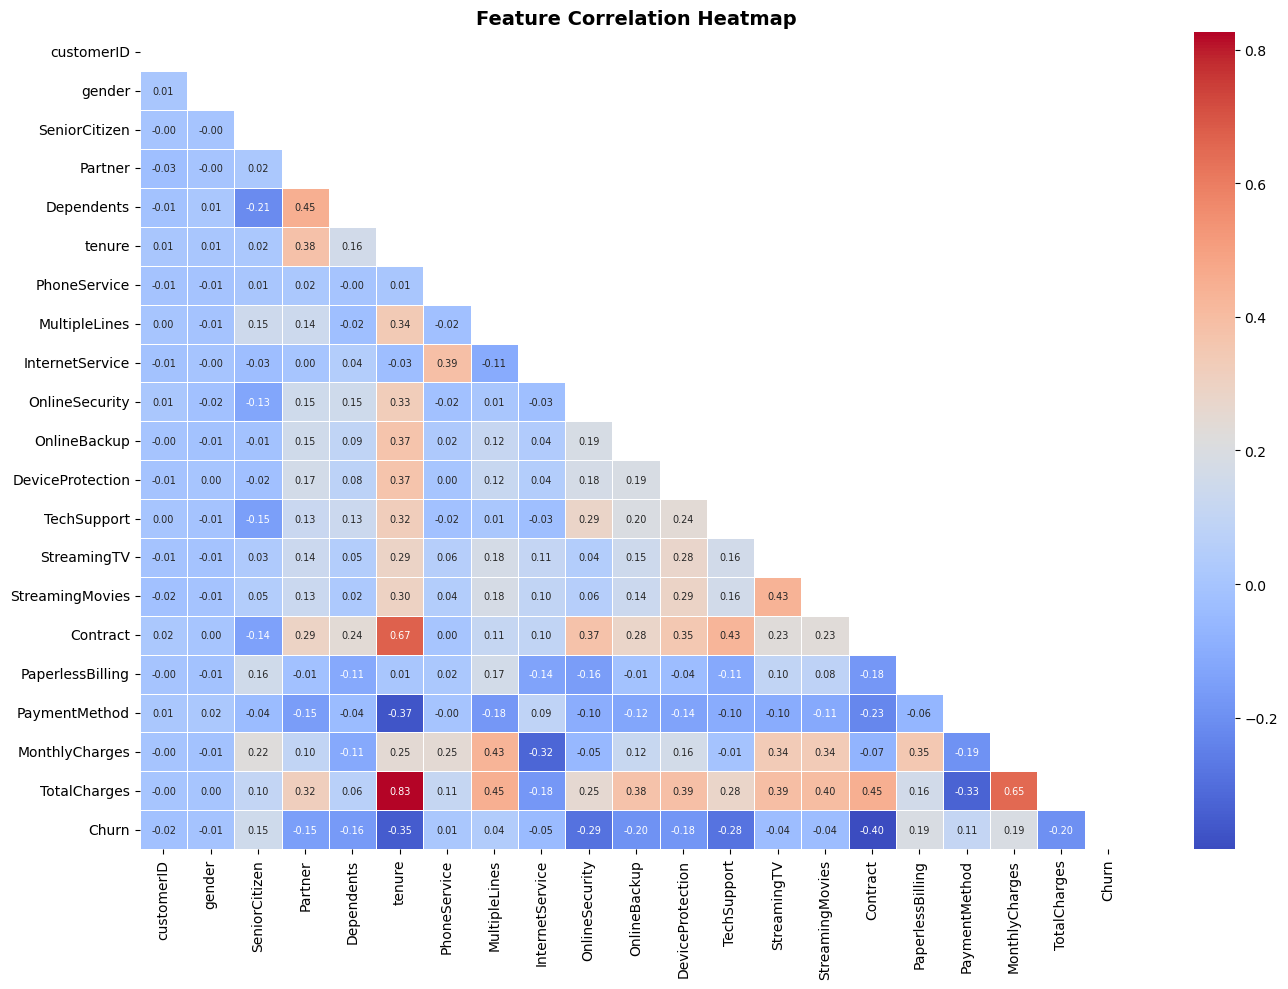

In [144]:
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14,10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size":7})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig("plot_heatmap.png")
plt.show()

In [145]:
corr_matrix = df.corr(numeric_only=True).abs()

high_corr = (
    corr_matrix.where(corr_matrix > 0.8)
    .stack()
)

print(high_corr)

SeniorCitizen   SeniorCitizen     1.00000
tenure          tenure            1.00000
                TotalCharges      0.82588
MonthlyCharges  MonthlyCharges    1.00000
TotalCharges    tenure            0.82588
                TotalCharges      1.00000
dtype: float64


In [146]:
df2 = pd.get_dummies(df, drop_first=True)
df2

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,False,False,False,False,False,False,...,True,False,True,True,False,True,False,False,True,False
7039,0,72,103.20,7362.90,False,False,False,False,False,False,...,True,False,True,True,False,True,True,False,False,False
7040,0,11,29.60,346.45,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
7041,1,4,74.40,306.60,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True


In [147]:
X = pd.get_dummies(df.drop(["Churn", "TotalCharges"], axis=1), drop_first=True)
y = df["Churn"]

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)

In [148]:
dict_importance = importances.sort_values(ascending=False).head(10).to_dict()
print(dict_importance)

{'tenure': 0.11799127165196956, 'MonthlyCharges': 0.09196989257100588, 'PaymentMethod_Electronic check': 0.02730757871637874, 'Contract_Two year': 0.026301167321898574, 'InternetService_Fiber optic': 0.024745183568765365, 'OnlineSecurity_Yes': 0.023404401283903312, 'TechSupport_Yes': 0.021433302905824174, 'Contract_One year': 0.02089633001535022, 'OnlineBackup_Yes': 0.01710912009408154, 'PaperlessBilling_Yes': 0.017059377930570954}


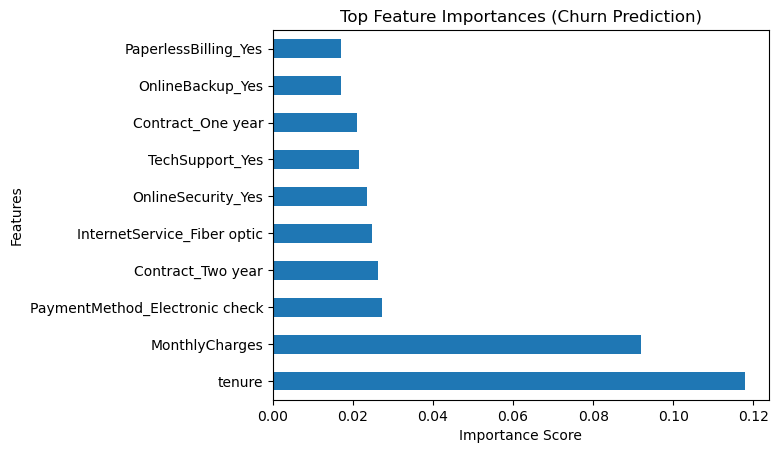

In [149]:
pd_importances = pd.Series(dict_importance)

plt.figure()
pd_importances.plot(kind="barh")

plt.title("Top Feature Importances (Churn Prediction)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.savefig(f"{parent_dir}/images/feature_imp.png")
plt.show()

In [150]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 20% test, 80% train
    random_state=42,    # reproducible results
    stratify=y       
# keeps class balance
)

In [151]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train churn ratio:\n", y_train.value_counts(normalize=True))
print("Test churn ratio:\n", y_test.value_counts(normalize=True))

Train shape: (4930, 7071)
Test shape: (2113, 7071)
Train churn ratio:
 Churn
No     0.734686
Yes    0.265314
Name: proportion, dtype: float64
Test churn ratio:
 Churn
No     0.734501
Yes    0.265499
Name: proportion, dtype: float64


In [152]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [153]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1552
         Yes       0.64      0.49      0.56       561

    accuracy                           0.79      2113
   macro avg       0.74      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



In [154]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1400  152]
 [ 285  276]]


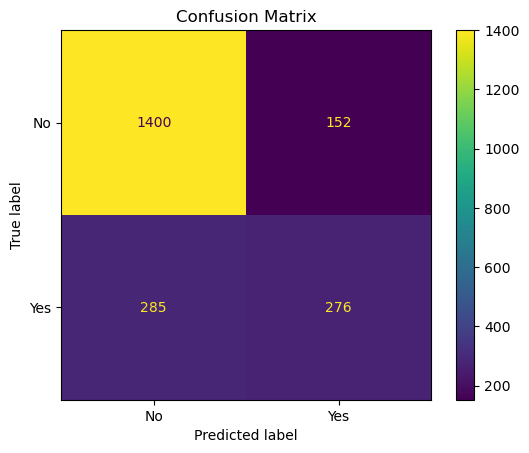

In [155]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
plt.title("Confusion Matrix")
plt.savefig(f"{parent_dir}/images/confusionmatrix")
plt.show()

In [156]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)

scores = cross_val_score(
    model,
    X_train, y_train,
    cv=5,              # 5-fold cross-validation
    scoring="accuracy"
)

print("Scores:", scores)
print("Average:", scores.mean())

Scores: [0.79716024 0.81034483 0.79716024 0.78600406 0.77281947]
Average: 0.7926977687626774


In [157]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(class_weight="balanced", random_state=42)
y_train = y_train.map({"No": 0, "Yes": 1})
scores = cross_val_score(
    model,
    X_train, y_train,
    cv=cv,
    scoring="f1"
)

print("F1 scores:", scores)
print("Average F1:", scores.mean())

F1 scores: [0.53456221 0.54464286 0.54505495 0.54704595 0.60721868]
Average F1: 0.555704929938226


In [158]:
scores = cross_val_score(
    model,
    X_train, y_train,
    cv=5,
    scoring="recall"   # focus on detecting churn
)

print("Recall scores:", scores)
print("Average recall:", scores.mean())

Recall scores: [0.46743295 0.47509579 0.49236641 0.46946565 0.45419847]
Average recall: 0.4717118539966658


### Build model with the top ten feature importance

In [159]:
print(dict_importance.keys())

dict_keys(['tenure', 'MonthlyCharges', 'PaymentMethod_Electronic check', 'Contract_Two year', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'TechSupport_Yes', 'Contract_One year', 'OnlineBackup_Yes', 'PaperlessBilling_Yes'])


In [160]:
X = X[dict_importance.keys()]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=42,  
    stratify=y       
)

model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [161]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.87      0.85      1552
         Yes       0.58      0.50      0.54       561

    accuracy                           0.77      2113
   macro avg       0.71      0.69      0.69      2113
weighted avg       0.76      0.77      0.77      2113



In [162]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1353  199]
 [ 281  280]]


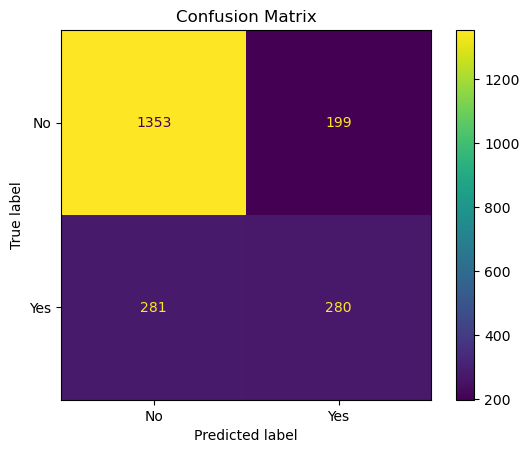

In [163]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

#### Logistic Regression

In [164]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

In [165]:
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [166]:
y_pred = log_model.predict(X_test)

In [167]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.91      0.71      0.80      1552
         Yes       0.50      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.70      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113



In [168]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1109  443]
 [ 114  447]]


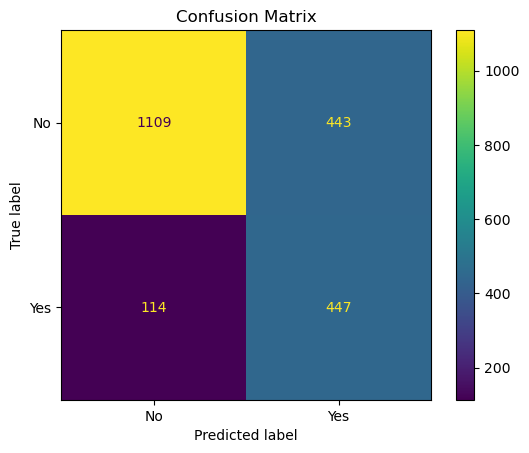

In [169]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [170]:
model = XGBClassifier(eval_metric="logloss")

In [171]:
y_train = y_train.map({"No": 0, "Yes": 1})
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [172]:
y_pred = model.predict(X_test)

In [173]:
y_test = y_test.map({"No": 0, "Yes": 1})
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1552
           1       0.59      0.50      0.54       561

    accuracy                           0.77      2113
   macro avg       0.71      0.69      0.70      2113
weighted avg       0.77      0.77      0.77      2113



In [174]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1357  195]
 [ 281  280]]


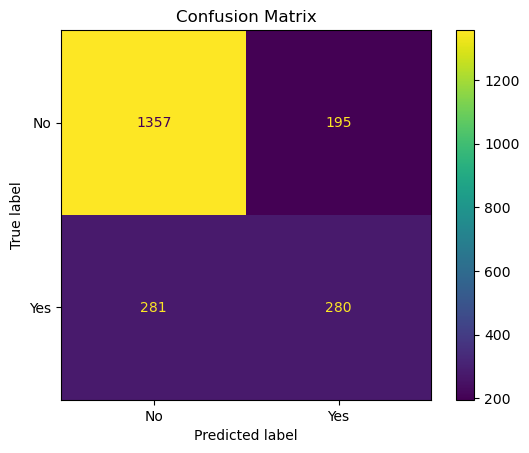

In [175]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()